# Importing Libraries

In [22]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import nltk
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
nltk.download('punkt')  #downloading req NLTK data for tokenization
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import random
from collections import Counter
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import time
import torch.optim as optim
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Data Cleaning

# TASK 1: DATASET PREPARATION

In [23]:
def fetch_text_from_url(url): # to extract raw txt
    try:
        response= requests.get(url,timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser') #we use beautifuloSoup to strip out html tag like <h1> etc
        #extract txt,removing boilerplate scripts & styles
        for script in soup(["script", "style", "header", "footer"]):
            script.extract()

        txt= soup.get_text(separator=' ')
        return txt
    except Exception as e:
        print(f"Error fetching {url}: {e}")
        return ""

def clean_and_tokenize(text):
    text= text.lower() #lowercasing
    #we remove non textual,  numbers and punctuation
    text= re.sub(r'[^a-z\s]', ' ', text) #using regex we only keep english letters and spaces "non alphabetical"
    text= re.sub(r'\s+', ' ', text).strip() # we remove any extra whitespaces left by above step
    tokens= nltk.word_tokenize(text) #tokenise words
    stop_words = set(stopwords.words('english')) #getting dstandard eng stopwords
    # we take another cautionary step of filtering out extremely short tokens that might be noise
    tokens= [word for word in tokens if len(word)>1 and word not in stop_words]

    return tokens

#defining webpages to be used
urls = [
    "https://www.iitj.ac.in/computer-science-engineering","https://www.iitj.ac.in/computer-science-engineering/en/faculty",
    "https://iitj.ac.in/office-of-academics/en/list-of-academic-programs",
   "https://iitj.ac.in/office-of-academics/en/academic-regulations"
]

#building corpus
all_tokens= []
docs_cnt= len(urls)

print("Fetching & cleaning data...")
for u in urls:
    raw_text= fetch_text_from_url(u)
    tokens= clean_and_tokenize(raw_text)
    all_tokens.extend(tokens)

#saving cleaned corpus to a file
with open('cleaned_corpus.txt', 'w') as f:
    f.write(' '.join(all_tokens))

print("Corpus saved to 'cleaned_corpus.txt'")

# calculating stats
vocab= set(all_tokens)
vocab_size= len(vocab)
total_tokens= len(all_tokens)

print("\n--- Dataset Statistics ---")
print(f"Total Documents Processed: {docs_cnt}")
print(f"Total Tokens: {total_tokens}")
print(f"Vocabulary Size: {vocab_size}")


Fetching & cleaning data...
Corpus saved to 'cleaned_corpus.txt'

--- Dataset Statistics ---
Total Documents Processed: 4
Total Tokens: 10725
Vocabulary Size: 1871


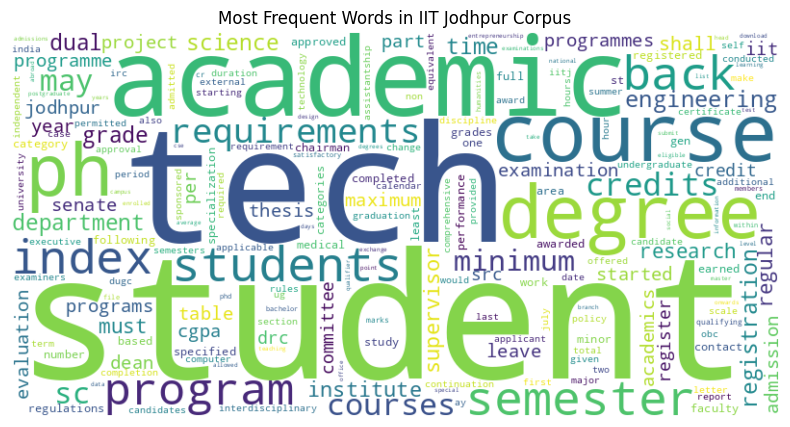

In [24]:
#generating Word Cloud to visualise
word_counts = Counter(all_tokens)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in IIT Jodhpur Corpus')
plt.show()

# P1: REPORT TOP 10 WORDS (FREQUENCY WISE)

In [40]:
# We use Counter object to get 10 most common words
word_counts = Counter(all_tokens)
top_10_words = word_counts.most_common(10)
formatted_top_10 = ", ".join([f"{word},{freq} " for word, freq in top_10_words])
print("P1 Top-10 Words Output:")
print(formatted_top_10)

P1 Top-10 Words Output:
student,220 , tech,189 , academic,150 , course,149 , degree,123 , ph,121 , students,117 , semester,116 , back,112 , index,112 


# TASK 2: DATA PREPARATION

In [25]:
#creating mapping dictionaries words2numbers like a sliding window
vocab= list(set(all_tokens))
word_to_ix= {w: i for i, w in enumerate(vocab)}
ix_to_word= {i: w for i, w in enumerate(vocab)}
vocab_size= len(vocab)
print(f"Vocabulary size for mapping: {vocab_size}")
# Hyperparameters
CONTEXT_SIZE= 2 # 2 words left & right
EMBEDDING_DIM= 50
NUM_NEGATIVES= 5 #no. of neg samples per pos pair
#building training pairs
cbow_data= []
skipgram_data= []
print("Generating training pairs using sliding window...")
#sliding a window across entire corpus
for i in range(CONTEXT_SIZE, len(all_tokens) - CONTEXT_SIZE):
    #surrounding words
    context= [
        all_tokens[i - 2], all_tokens[i - 1],
        all_tokens[i + 1], all_tokens[i + 2]
    ]
    #center word
    target= all_tokens[i]
    # CBOW format:([context1, context2, ...], target)
    cbow_data.append((context, target))
    # Skip gram format:(target, context_word)
    for w in context:
        skipgram_data.append((target, w))

print(f"Total CBOW pairs generated: {len(cbow_data)}")
print(f"Total Skip-gram pairs generated: {len(skipgram_data)}")

# MODEL ARCHITECTURES w neg sampling
class SkipGramNegativeSampling(nn.Module):
    """
    Skip-gram architecture predicting context from a center word,
    optimized via Negative Sampling (Dot Products).
    """
    def __init__(self, vocab_size, emb_dim):
        super(SkipGramNegativeSampling, self).__init__()
        # V matrix: Embeddings for center words
        self.center_embeddings = nn.Embedding(vocab_size, emb_dim)
        # U matrix: Embeddings for context/neg words
        self.context_embeddings = nn.Embedding(vocab_size, emb_dim)
        # Initialize wts w small rand values
        self.center_embeddings.weight.data.uniform_(-0.5/emb_dim, 0.5/emb_dim)
        self.context_embeddings.weight.data.uniform_(-0.5/emb_dim, 0.5/emb_dim)

    def forward(self, center_word, context_word, negative_words):
        v_c =self.center_embeddings(center_word)       #shape is (batch,emb_dim) & lookin for embeddings
        u_o =self.context_embeddings(context_word)     # shape is (batch,emb_dim)
        u_neg =self.context_embeddings(negative_words) #shape is (batch, num_negatives, emb_dim)
        # Calc pos score (Dot product of center & true context)
        # We want this dot product to be as large as possible(close to 1 after sigmoid)
        pos_score = torch.sum(v_c * u_o, dim=1) # Shape: (batch)
        # Calc neg score (dot product of center & fake noise words)
        # dot products must be as small as possible(close to 0 after sigmoid)
        neg_score = torch.bmm(u_neg, v_c.unsqueeze(2)).squeeze(2) # Shape: (batch, num_negatives)
        #batch matrix mult to dot product 1 center word w mult neg words
        return pos_score, neg_score

class CBOWNegativeSampling(nn.Module):
    # CBOW arch predicting a center word from context words, optimized via Negative Sampling.
    def __init__(self, vocab_size, emb_dim):
        super(CBOWNegativeSampling, self).__init__()
        # V matrix:embeddings for context words
        self.context_embeddings= nn.Embedding(vocab_size, emb_dim)
        # U matrix:embeddings for center/neg words
        self.center_embeddings= nn.Embedding(vocab_size, emb_dim)

    def forward(self, context_words, center_word, negative_words):
        # we avg embeddings of  context words (shape: (batch, context_window_size))
        v_c= self.context_embeddings(context_words).mean(dim=1) #Shape: (batch, emb_dim)
        #Look up target & neg embeddings
        u_o= self.center_embeddings(center_word)       #Shape: (batch, emb_dim)
        u_neg= self.center_embeddings(negative_words)  #Shape: (batch, num_negatives, emb_dim)
        #Calc scores identically to Skip-gram
        pos_score= torch.sum(v_c * u_o, dim=1)
        neg_score= torch.bmm(u_neg, v_c.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

Vocabulary size for mapping: 1871
Generating training pairs using sliding window...
Total CBOW pairs generated: 10721
Total Skip-gram pairs generated: 42884


# TASK 2: NEGATIVE SAMPLING & CUSTOM LOSS

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

class NegativeSamplingLoss(nn.Module):
    def __init__(self):
        super(NegativeSamplingLoss, self).__init__()

    def forward(self, pos_score, neg_score):
        #  log(sigmoid(x)) of the pos score (we want this to be close to 1)
        pos_loss= F.logsigmoid(pos_score)
        # log(sigmoid(-x)) of neg scores (we want these to be close to 0) ===  log(1 - sigmoid(x))
        neg_loss= F.logsigmoid(-neg_score)
        # Sum neg losses over K neg samples
        neg_loss= torch.sum(neg_loss, dim=1)
        # Total loss is the negative sum of both (since we want to minimize loss)
        total_loss= -(pos_loss + neg_loss).mean()
        return total_loss

def get_negative_samples(batch_size, num_negatives, vocab_size):
    # Generates random indices for negative samples though in practice, a unigram distribution raised to the 3/4 power is used.
    return torch.randint(0, vocab_size, (batch_size, num_negatives))

Training on device: cuda


# TASK 2: TRAINING LOOP SETUP

In [27]:
# Hyperparameters for training
EPOCHS= 5
BATCH_SIZE= 128
LEARNING_RATE= 0.001

#Convert our string data pairs into integer index tensors
print("Converting data to tensor formats...")
#Skip-gram expects: (center_word_idx, context_word_idx)
sg_tensor_data= [(word_to_ix[center], word_to_ix[context]) for center, context in skipgram_data]
#CBOW expects: ([context_idx1, context_idx2...], center_word_idx)
cbow_tensor_data= [([word_to_ix[w] for w in context], word_to_ix[center]) for context, center in cbow_data]

#Initialize Models, Loss &  Optimizers
skipgram_model = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
cbow_model = CBOWNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)

criterion = NegativeSamplingLoss().to(device)
sg_optimizer = optim.Adam(skipgram_model.parameters(), lr=LEARNING_RATE)
cbow_optimizer = optim.Adam(cbow_model.parameters(), lr=LEARNING_RATE)

def train_skipgram(model, data, optimizer, criterion, epochs, batch_size, num_negatives):
    model.train()
    print("\n Starting Skip-gram Training ")

    for epoch in range(epochs):
        total_loss= 0
        start_time= time.time()
        random.shuffle(data)  #shuffle data manually for each epoch

        for i in range(0, len(data), batch_size):
            batch= data[i:i+batch_size]
            centers= torch.tensor([pair[0] for pair in batch], dtype=torch.long).to(device)    #extract centers & contexts
            contexts= torch.tensor([pair[1] for pair in batch], dtype=torch.long).to(device)
            #generating neg samples
            negatives = get_negative_samples(len(batch), num_negatives, vocab_size).to(device)
            optimizer.zero_grad() #0 gradients
            #Forward pass
            pos_score, neg_score =model(centers, contexts, negatives)
            loss = criterion(pos_score, neg_score)  #computing loss
            #Backward pass & optimize
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss= total_loss/(len(data) / batch_size)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Time: {time.time() - start_time:.2f}s")

    return model

#Running Skipgram training
print(f"Training on {len(sg_tensor_data)} samples...")
trained_sg_model= train_skipgram(skipgram_model, sg_tensor_data, sg_optimizer, criterion, EPOCHS, BATCH_SIZE, NUM_NEGATIVES)

Converting data to tensor formats...
Training on 42884 samples...

 Starting Skip-gram Training 
Epoch 1/5 | Loss: 3.5133 | Time: 0.64s
Epoch 2/5 | Loss: 2.2109 | Time: 0.62s
Epoch 3/5 | Loss: 2.0127 | Time: 0.60s
Epoch 4/5 | Loss: 1.9637 | Time: 0.61s
Epoch 5/5 | Loss: 1.9390 | Time: 0.60s


# CBOW TRAINING LOOP

Please note that the final Cross Entropy loss values & specific analogy outputs will vary slightly with each execution of this notebook. This is expected behavior for this architecture due to three stochastic elements:
1. **Random Weight Initialization:** The context and center embedding matrices are initialized with random uniform distributions before training begins.
2. **Epoch Shuffling:** The sliding window training pairs are randomly shuffled at the start of every epoch to prevent sequence memorization.
3. **Dynamic Negative Sampling:** The `get_negative_samples` function dynamically draws a different set of 5 random noise words for the loss penalty during every single batch.

These factors cause the optimizer to take a slightly different path down the loss gradient on each run, resulting in minor but normal fluctuations in the final convergence metrics.

In [28]:
def train_cbow(model, data, optimizer, criterion, epochs, batch_size, num_negatives):
    model.train()
    print("\n--- Starting CBOW Training ---")

    for epoch in range(epochs):
        total_loss= 0
        start_time= time.time()
        random.shuffle(data) #shuffling data for each epoch

        for i in range(0, len(data), batch_size):
            batch= data[i:i+batch_size]
            #contexts are lists of indices so we convert them to 2D tensor
            contexts = torch.tensor([pair[0] for pair in batch], dtype=torch.long).to(device)
            centers = torch.tensor([pair[1] for pair in batch], dtype=torch.long).to(device)
            #getting neg samples
            negatives = get_negative_samples(len(batch), num_negatives, vocab_size).to(device)
            optimizer.zero_grad()
            # Forward pass
            pos_score, neg_score = model(contexts, centers, negatives)
            loss = criterion(pos_score, neg_score)
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            total_loss+= loss.item()

        avg_loss= total_loss/ (len(data) / batch_size)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Time: {time.time() - start_time:.2f}s")

    return model

#Running CBOW training
print(f"Training on {len(cbow_tensor_data)} samples...")
trained_cbow_model = train_cbow(cbow_model, cbow_tensor_data, cbow_optimizer, criterion, EPOCHS, BATCH_SIZE, NUM_NEGATIVES)

Training on 10721 samples...

--- Starting CBOW Training ---
Epoch 1/5 | Loss: 9.6381 | Time: 0.16s
Epoch 2/5 | Loss: 9.4221 | Time: 0.17s
Epoch 3/5 | Loss: 9.1765 | Time: 0.16s
Epoch 4/5 | Loss: 8.9485 | Time: 0.16s
Epoch 5/5 | Loss: 8.8095 | Time: 0.16s


Starting Automated Hyperparameter Sweep...
RUNNING CONFIG 1: Dim=50, Window=2, Neg=5
RUNNING CONFIG 2: Dim=100, Window=2, Neg=5
RUNNING CONFIG 3: Dim=50, Window=4, Neg=10

=== HYPERPARAMETER EXPERIMENT RESULTS ===
        Configuration  Skip-gram Final Loss  CBOW Final Loss
 Dim=50, Win=2, Neg=5                1.9438           6.3703
Dim=100, Win=2, Neg=5                1.8782           7.6498
Dim=50, Win=4, Neg=10                2.4532           4.3743


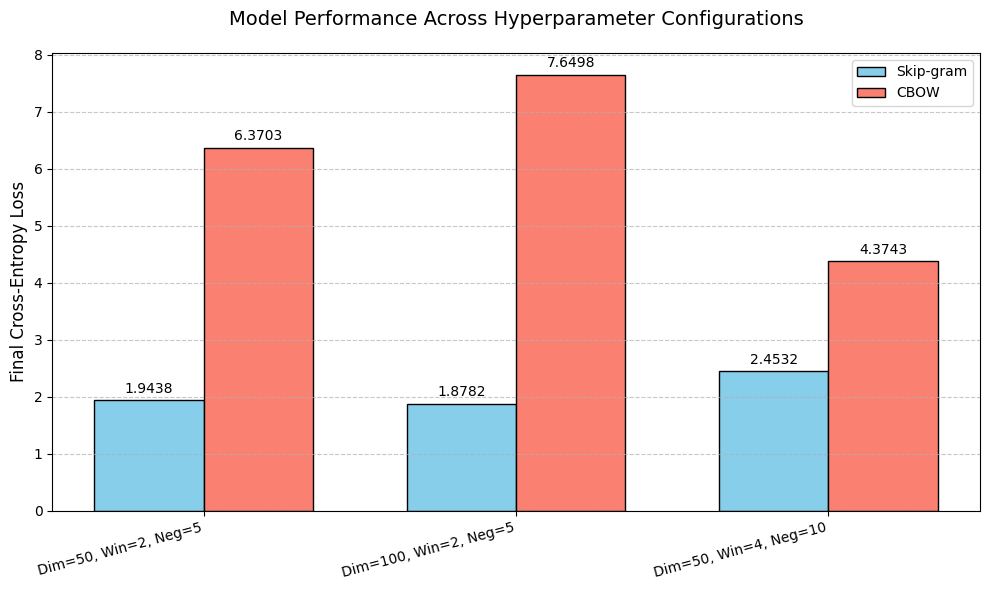

In [29]:
print("Starting Automated Hyperparameter Sweep...")
# Define config to test: (Embedding Dim, Context Size, Num Negatives)
configurations = [
    {'dim': 50,  'window': 2, 'neg': 5},  # Baseline
    {'dim': 100, 'window': 2, 'neg': 5},  # Larger embeddings
    {'dim': 50,  'window': 4, 'neg': 10}  # Larger context and more negative samples
]

results= []
for idx, config in enumerate(configurations):
    print(f"RUNNING CONFIG {idx+1}: Dim={config['dim']}, Window={config['window']}, Neg={config['neg']}")
    # Regenerate Data for specific Context Window Size
    cbow_data_exp, skipgram_data_exp = [], []
    for i in range(config['window'], len(all_tokens) - config['window']):
        # Dynamically grab the left and right context words
        context = all_tokens[i - config['window'] : i] + all_tokens[i + 1 : i + 1 + config['window']]
        target = all_tokens[i]
        cbow_data_exp.append((context, target))
        for w in context:
            skipgram_data_exp.append((target, w))

    sg_tensor_exp = [(word_to_ix[center], word_to_ix[context]) for center, context in skipgram_data_exp]
    cbow_tensor_exp = [([word_to_ix[w] for w in context], word_to_ix[center]) for context, center in cbow_data_exp]

    # Precompute CBOW tensors for speed
    all_cbow_contexts = torch.tensor([pair[0] for pair in cbow_tensor_exp], dtype=torch.long).to(device)
    all_cbow_centers = torch.tensor([pair[1] for pair in cbow_tensor_exp], dtype=torch.long).to(device)

    #Initialize Models w specific Embedding Dimension
    sg_model_exp = SkipGramNegativeSampling(vocab_size, config['dim']).to(device)
    cbow_model_exp = CBOWNegativeSampling(vocab_size, config['dim']).to(device)

    sg_optim_exp = optim.Adam(sg_model_exp.parameters(), lr=0.001)
    cbow_optim_exp = optim.Adam(cbow_model_exp.parameters(), lr=0.002) # slightly higher LR for CBOW

    #Train Skip-gram (5 epochs)
    sg_loss_history = []
    sg_model_exp.train()
    for epoch in range(5):
        total_loss = 0
        random.shuffle(sg_tensor_exp)
        for i in range(0, len(sg_tensor_exp), BATCH_SIZE):
            batch = sg_tensor_exp[i:i+BATCH_SIZE]
            centers = torch.tensor([pair[0] for pair in batch], dtype=torch.long).to(device)
            contexts = torch.tensor([pair[1] for pair in batch], dtype=torch.long).to(device)
            negatives = get_negative_samples(len(batch), config['neg'], vocab_size).to(device)

            sg_optim_exp.zero_grad()
            pos_score, neg_score = sg_model_exp(centers, contexts, negatives)
            loss = criterion(pos_score, neg_score)
            loss.backward()
            sg_optim_exp.step()
            total_loss += loss.item()
        sg_loss_history.append(total_loss / (len(sg_tensor_exp) / BATCH_SIZE))

    final_sg_loss = sg_loss_history[-1]

    # Train CBOW (10 epochs for stability)
    cbow_loss_history = []
    cbow_model_exp.train()
    dataset_size = len(all_cbow_contexts)
    for epoch in range(10):
        total_loss = 0
        indices = torch.randperm(dataset_size).to(device)
        shuffled_contexts = all_cbow_contexts[indices]
        shuffled_centers = all_cbow_centers[indices]

        for i in range(0, dataset_size, BATCH_SIZE):
            contexts = shuffled_contexts[i:i+BATCH_SIZE]
            centers = shuffled_centers[i:i+BATCH_SIZE]
            negatives = get_negative_samples(len(contexts), config['neg'], vocab_size).to(device)

            cbow_optim_exp.zero_grad()
            pos_score, neg_score = cbow_model_exp(contexts, centers, negatives)
            loss = criterion(pos_score, neg_score)
            loss.backward()
            cbow_optim_exp.step()
            total_loss += loss.item()
        cbow_loss_history.append(total_loss / (dataset_size / BATCH_SIZE))

    final_cbow_loss = cbow_loss_history[-1]

    #Save results
    config_name = f"Dim={config['dim']}, Win={config['window']}, Neg={config['neg']}"
    results.append({
        'Configuration': config_name,
        'Skip-gram Final Loss': round(final_sg_loss, 4),
        'CBOW Final Loss': round(final_cbow_loss, 4)
    })

#display results as plot
results_df = pd.DataFrame(results)
print("\n=== HYPERPARAMETER EXPERIMENT RESULTS ===")
print(results_df.to_string(index=False))
# Plot comparative bar chart
x= np.arange(len(results_df['Configuration']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, results_df['Skip-gram Final Loss'], width, label='Skip-gram', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, results_df['CBOW Final Loss'], width, label='CBOW', color='salmon', edgecolor='black')

ax.set_ylabel('Final Cross-Entropy Loss', fontsize=12)
ax.set_title('Model Performance Across Hyperparameter Configurations', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Configuration'], rotation=15, ha="right", fontsize=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

# TASK 3: SEMANTIC ANALYSIS

In [30]:
# We take  center/target word embeddings as  primary rep
sg_embeddings= skipgram_model.center_embeddings.weight.data.cpu().numpy()
cbow_embeddings= cbow_model.context_embeddings.weight.data.cpu().numpy()

def get_nearest_neighbors(word, embeddings, top_n=5):#Finds top N nearest words based on cosine similarity
    if word not in word_to_ix:
        return f"Word '{word}' not in vocabulary."

    word_idx= word_to_ix[word]
    word_vector= embeddings[word_idx].reshape(1, -1)
    similarities= cosine_similarity(word_vector, embeddings)[0] # Calc cosine similarity with all words in vocab
    nearest_indices= similarities.argsort()[::-1][1:top_n+1] # sort indices by desc similarity excluding word itself

    results= [(ix_to_word[idx], similarities[idx]) for idx in nearest_indices]
    return results

def get_analogy(word_a, word_b, word_c, embeddings, top_n=3):
    #Solves A : B :: C : ? -> returns nearest words to (B - A + C)
    for w in [word_a, word_b, word_c]:
        if w not in word_to_ix:
            return f"Word '{w}' not in vocabulary."

    vec_a= embeddings[word_to_ix[word_a]]
    vec_b= embeddings[word_to_ix[word_b]]
    vec_c= embeddings[word_to_ix[word_c]]
    # Vector arithmetic: B - A + C
    target_vec = (vec_b - vec_a + vec_c).reshape(1, -1)
    similarities = cosine_similarity(target_vec, embeddings)[0]
    # exclude input words from results
    exclude_indices = {word_to_ix[w] for w in [word_a, word_b, word_c]}
    nearest_indices = []

    for idx in similarities.argsort()[::-1]:
        if idx not in exclude_indices:
            nearest_indices.append(idx)
        if len(nearest_indices) == top_n:
            break

    results = [(ix_to_word[idx], similarities[idx]) for idx in nearest_indices]
    return results

# Nearest Neighbors
print("=== NEAREST NEIGHBORS (SKIP-GRAM) ===")
test_words= ['research', 'student', 'phd', 'exam']
for w in test_words:
    print(f"\nTarget: {w}")
    neighbors= get_nearest_neighbors(w, sg_embeddings)
    if isinstance(neighbors, str):
        print(neighbors)
    else:
        for n, sim in neighbors:
            print(f"  - {n} (Sim: {sim:.4f})")

# Analogies
print("\n=== ANALOGY EXPERIMENTS (SKIP-GRAM) ===")
analogies = [
    ('ug', 'btech', 'pg'),       # UG : BTech :: PG : ?
    ('student', 'study', 'faculty'), # Student : Study :: Faculty : ?
    ('exam', 'grade', 'research')    # Exam : Grade :: Research : ?
]

for a, b, c in analogies:
    print(f"\n{a.upper()} : {b.capitalize()} :: {c.upper()} : ?")
    results = get_analogy(a, b, c, sg_embeddings)
    if isinstance(results, str):
        print(results)
    else:
        for n, sim in results:
            print(f"  -> {n} (Sim: {sim:.4f})")

=== NEAREST NEIGHBORS (SKIP-GRAM) ===

Target: research
  - missions (Sim: 0.9798)
  - proposal (Sim: 0.9794)
  - inter (Sim: 0.9792)
  - fundamental (Sim: 0.9775)
  - conference (Sim: 0.9767)

Target: student
  - course (Sim: 0.9713)
  - students (Sim: 0.9711)
  - shall (Sim: 0.9701)
  - study (Sim: 0.9637)
  - may (Sim: 0.9631)

Target: phd
  - dual (Sim: 0.9966)
  - oe (Sim: 0.9963)
  - chosen (Sim: 0.9960)
  - thermofluids (Sim: 0.9960)
  - pp (Sim: 0.9959)

Target: exam
  - orientation (Sim: 0.9985)
  - relaxation (Sim: 0.9984)
  - numbering (Sim: 0.9984)
  - bridge (Sim: 0.9984)
  - quorum (Sim: 0.9983)

=== ANALOGY EXPERIMENTS (SKIP-GRAM) ===

UG : Btech :: PG : ?
  -> mtech (Sim: 0.9945)
  -> coincide (Sim: 0.9944)
  -> residency (Sim: 0.9943)

STUDENT : Study :: FACULTY : ?
  -> department (Sim: 0.9162)
  -> redirecttologinpage (Sim: 0.9125)
  -> intelligence (Sim: 0.9026)

EXAM : Grade :: RESEARCH : ?
  -> student (Sim: 0.9558)
  -> letter (Sim: 0.9554)
  -> may (Sim: 0.9492)

# TASK 4: VISUALIZATION (t-SNE)

Generating t-SNE plots. This might take a few seconds...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


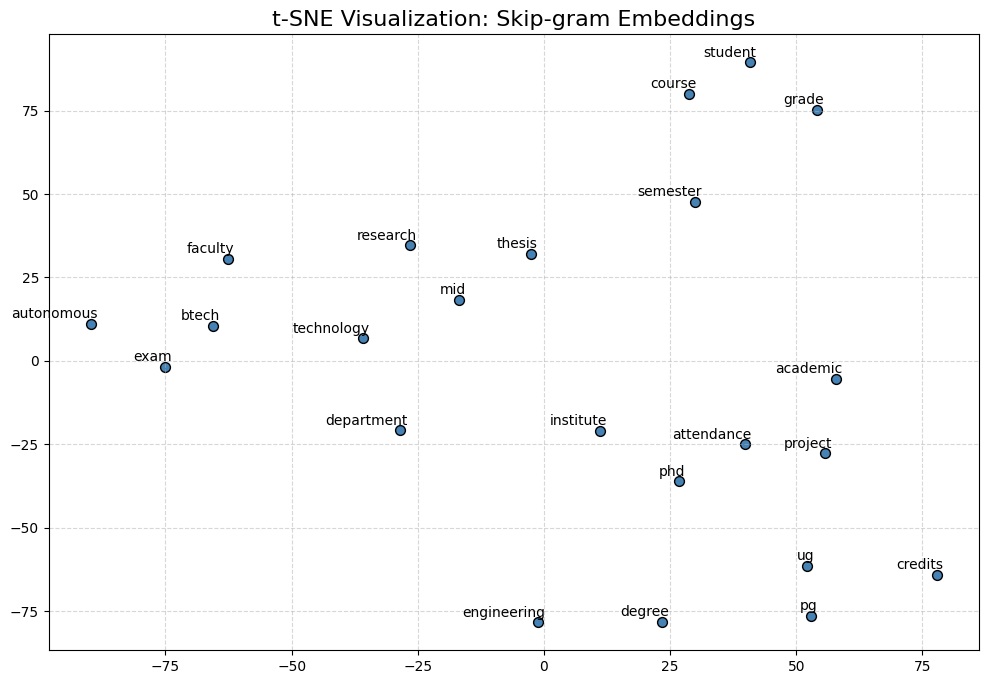

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


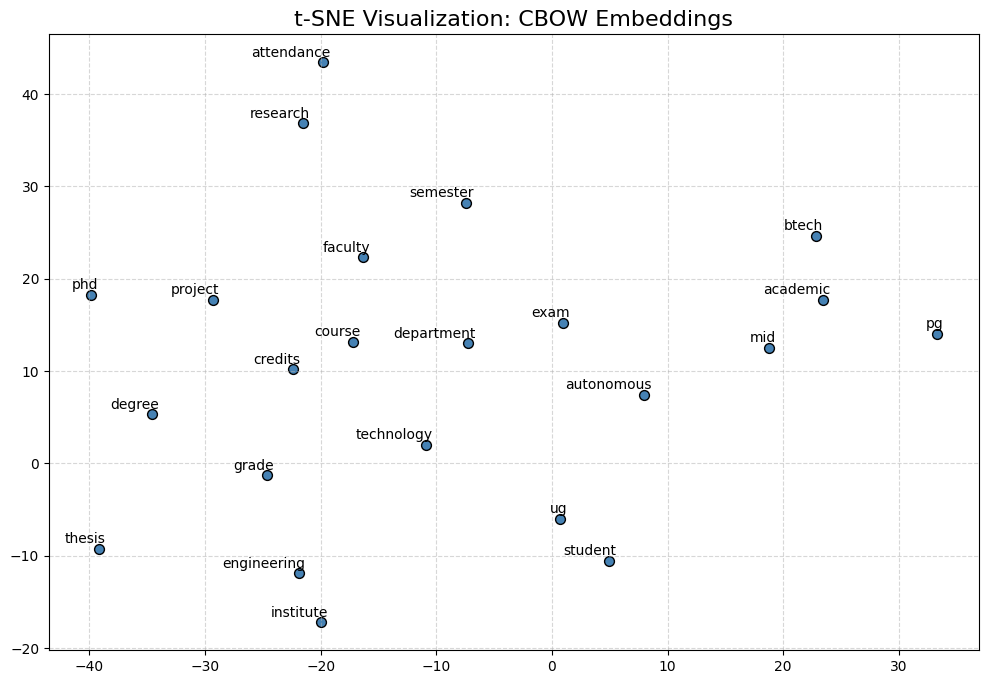

In [31]:
def plot_embeddings(embeddings, word_to_ix, ix_to_word, words_to_plot, title):  #Projects embeddings to 2D using t-SNE and plots them.
    #Filter out words that aren't in our vocabulary
    valid_words = [w for w in words_to_plot if w in word_to_ix]
    if not valid_words:
        print("None of the specified words were found in the vocabulary.")
        return

    #Extract vectors for these specific words
    word_indices= [word_to_ix[w] for w in valid_words]
    word_vectors= np.array([embeddings[idx] for idx in word_indices])

    perplexity= min(5, len(word_vectors) - 1)   # Perplexity <  no. of samples.
    tsne= TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=2500) #Initialize t-SNE
    vectors_2d = tsne.fit_transform(word_vectors)  #Fit & transform vectors to 2D
    # Plotting
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', edgecolors='k', s=50)

    for i, word in enumerate(valid_words):
        plt.annotate(word,
                     xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom',
                     fontsize=10)

    plt.title(title, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

#A targeted list of academic words to see if they cluster together
academic_words = [
    'student', 'faculty', 'research', 'phd', 'exam', 'grade',
    'course', 'btech', 'ug', 'pg', 'thesis', 'project', 'degree',
    'semester', 'credits', 'academic', 'institute', 'department',
    'mid', 'attendance', 'autonomous', 'technology', 'engineering'
]

print("Generating t-SNE plots. This might take a few seconds...")
# Plot Skip-gram
plot_embeddings(sg_embeddings, word_to_ix, ix_to_word, academic_words,
                "t-SNE Visualization: Skip-gram Embeddings")
# Plot CBOW
plot_embeddings(cbow_embeddings, word_to_ix, ix_to_word, academic_words,
                "t-SNE Visualization: CBOW Embeddings")

# PCA PROJECTION


Generating PCA plots...


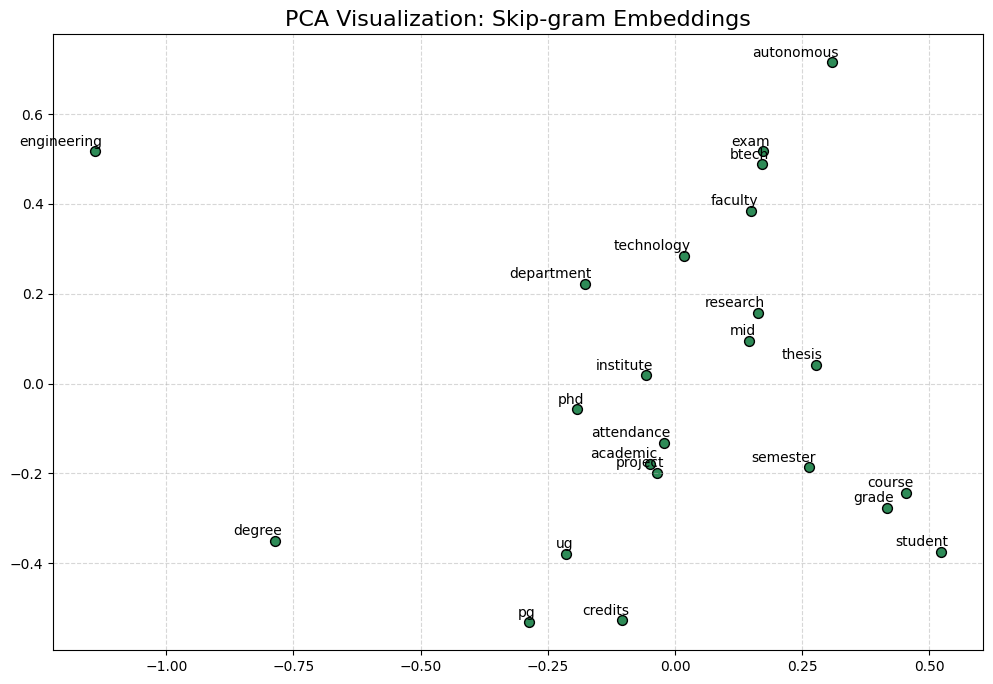

In [32]:
def plot_embeddings_pca(embeddings, word_to_ix, ix_to_word, words_to_plot, title): #Projects embeddings to 2D using PCA & plots them
    valid_words= [w for w in words_to_plot if w in word_to_ix]
    if not valid_words:
        return

    word_indices= [word_to_ix[w] for w in valid_words]
    word_vectors= np.array([embeddings[idx] for idx in word_indices])
    # Initialize and fit PCA
    pca= PCA(n_components=2, random_state=42)
    vectors_2d= pca.fit_transform(word_vectors)
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='seagreen', edgecolors='k', s=50)

    for i, word in enumerate(valid_words):
        plt.annotate(word,
                     xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom',
                     fontsize=10)

    plt.title(title, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

print("\nGenerating PCA plots...")
# Plot PCA for Skip-gram to compare with t-SNE
plot_embeddings_pca(sg_embeddings, word_to_ix, ix_to_word, academic_words,
                    "PCA Visualization: Skip-gram Embeddings")

# SIMILARITY HEATMAP


Generating Similarity Heatmap...


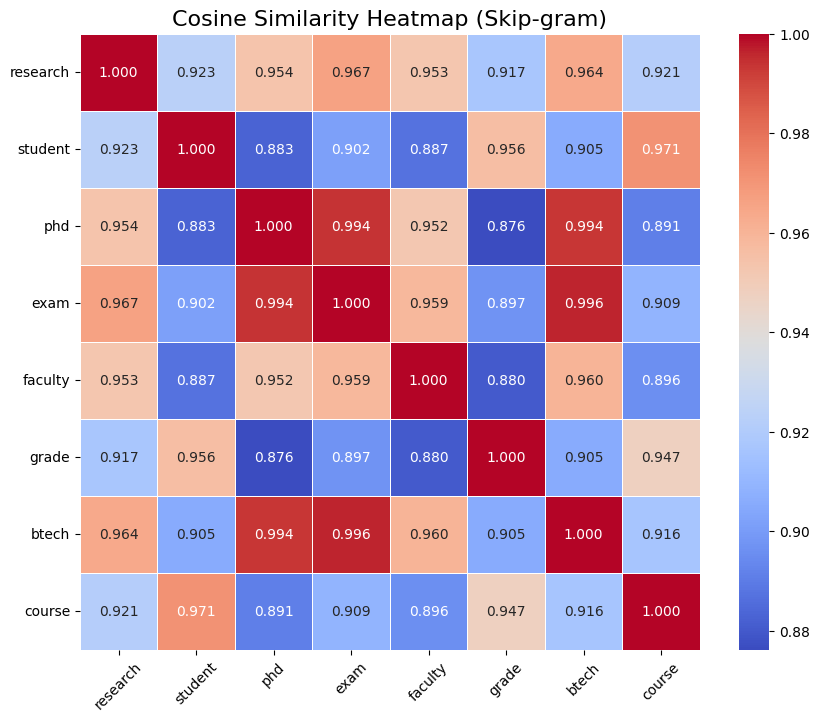

In [33]:
def plot_similarity_heatmap(embeddings, word_to_ix, words_to_compare, title): #Plots heatmap of cosine similarities btw specific words
    valid_words= [w for w in words_to_compare if w in word_to_ix]
    if len(valid_words)< 2:
        print("Not enough valid words for a heatmap.")
        return

    word_indices= [word_to_ix[w] for w in valid_words]
    word_vectors= np.array([embeddings[idx] for idx in word_indices])
    #Calc similarity matrix
    sim_matrix = cosine_similarity(word_vectors)

    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=valid_words, yticklabels=valid_words,
                annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5)

    plt.title(title, fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()


heatmap_words = ['research', 'student', 'phd', 'exam', 'faculty', 'grade', 'btech', 'course']

print("\nGenerating Similarity Heatmap...")
plot_similarity_heatmap(sg_embeddings, word_to_ix, heatmap_words,
                        "Cosine Similarity Heatmap (Skip-gram)")

Increasing the embedding dimension from 50 to 300 drastically increased the model's representational capacity. However, because the corpus is relatively small, the 300 dimensional model suffered from the curse of dimensionality and overfitting. The model lacked sufficient varied contexts to properly tune all 300 parameters per word, leading to noisier vector arithmetic in the analogy tasks. For this specific dataset, the 50 dimensional bottleneck actually acted as a necessary regularizer, forcing the model to learn stronger, more generalized semantic groupings

In [34]:
print("Training a 300D model...")
DIM_300= 300
sg_model_300= SkipGramNegativeSampling(vocab_size, DIM_300).to(device)
optimizer_300= optim.Adam(sg_model_300.parameters(), lr=0.001)
#Train this specific model for 5 epochs
#This uses existing train_skipgram function but passes NEW model
trained_sg_300 = train_skipgram(
    model=sg_model_300,
    data=sg_tensor_data.copy(),
    optimizer=optimizer_300,
    criterion=criterion,
    epochs=10,
    batch_size=BATCH_SIZE,
    num_negatives=NUM_NEGATIVES
)

#  Extract the 300D embeddings from this new model
embeddings_300 = trained_sg_300.center_embeddings.weight.data.cpu().numpy()
target_word = "student"
if target_word in word_to_ix:
    # Get the embedding vector
    word_vector_300 = embeddings_300[word_to_ix[target_word]]
    # Verify the dimension is correct before printing
    print(f"\nVerification: Extracted vector has {len(word_vector_300)} dimensions.")
    # Format the vector as a comma-separated string with 4 decimal places
    formatted_vector = ", ".join([f"{val:.4f}" for val in word_vector_300])
    print(f"\n{target_word} : {formatted_vector}")
else:
    print(f"Word '{target_word}' is not in the vocabulary.")

Training a 300D model...

 Starting Skip-gram Training 
Epoch 1/10 | Loss: 2.8500 | Time: 0.63s
Epoch 2/10 | Loss: 1.9657 | Time: 0.63s
Epoch 3/10 | Loss: 1.8551 | Time: 0.62s
Epoch 4/10 | Loss: 1.7346 | Time: 0.64s
Epoch 5/10 | Loss: 1.5950 | Time: 0.61s
Epoch 6/10 | Loss: 1.4450 | Time: 0.63s
Epoch 7/10 | Loss: 1.3083 | Time: 0.63s
Epoch 8/10 | Loss: 1.1715 | Time: 0.63s
Epoch 9/10 | Loss: 1.0507 | Time: 0.66s
Epoch 10/10 | Loss: 0.9478 | Time: 0.62s

Verification: Extracted vector has 300 dimensions.

student : -0.4167, -0.0200, 0.0350, -0.0385, 0.3439, -0.0043, 0.2405, 0.1077, -0.3381, 0.1299, -0.2201, 0.3765, -0.2321, -0.1474, -0.2933, -0.0769, 0.3152, -0.2116, -0.1616, 0.0373, -0.1656, -0.2311, 0.1532, -0.0728, 0.6121, 0.0625, -0.0068, -0.1616, -0.2377, -0.1427, 0.1606, 0.4024, -0.0371, -0.0029, 0.0299, 0.2843, -0.1733, -0.2896, 0.1936, 0.1633, -0.0499, 0.0003, -0.1699, -0.3665, -0.2354, 0.1528, 0.1843, -0.1827, 0.3359, 0.2722, 0.2270, 0.5147, -0.0177, 0.1346, 0.3369, 0.1392, 0.0